In [1]:
!pip install xlrd

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_excel(r'C:\Users\cex\Downloads\default of credit card clients.xlsx',
                   header=0, skiprows=[0])

#remove first column
df = df.iloc[:, 1:]
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
print(df['EDUCATION'].value_counts())
print(df['MARRIAGE'].value_counts())
df['EDUCATION']= df['EDUCATION'].replace([0,5,6], 4)
df['MARRIAGE']= df['MARRIAGE'].replace([0], 3)

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [3]:
#split in train and test sets
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.3, random_state= 42, stratify= y)
#split test set in test and val
x_val, x_test1, y_val, y_test1= train_test_split( x_test,y_test, test_size= 0.5, random_state= 42, stratify=y_test)

In [4]:
#scaling
scaler= StandardScaler()
x_training_scaled= scaler.fit_transform(x_train)
x_val_scaled= scaler.transform(x_val)
x_test_scaled= scaler.transform(x_test)

In [5]:
#convert data to pytorch tensor
import torch
x_train_tens= torch.tensor(x_training_scaled, dtype= torch.float32)
y_train_tens= torch.tensor(y_train, dtype= torch.float32)
x_val_tens= torch.tensor(x_val_scaled, dtype= torch.float32)
y_val_tens= torch.tensor(y_val, dtype= torch.float32)
x_test_tens= torch.tensor(x_test_scaled, dtype= torch.float32)
y_test_tens= torch.tensor(y_test, dtype= torch.float32)

In [7]:
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(MLP, self).__init__()
        self.network= nn.Sequential(
        nn.Linear(23, 128), #hidden layer 1 from input
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(128, 64), #hidden layer 1 to hidden layer 2
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(64, 32), #hidden layer 2 to hidden layer 3
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(32,1),
        )
    def forward(self,x):
        return self.network(x)
model=MLP()
print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
criterion= nn.BCELoss()
optimiser= torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [9]:
from torch.utils.data import DataLoader, TensorDataset
#wrap tensors
train_ds= TensorDataset(x_train_tens, y_train_tens)
val_ds= TensorDataset(x_val_tens, y_val_tens)
val_ds= TensorDataset(x_val_tens, y_val_tens)
#data loaders
train_ld= DataLoader(train_ds, batch_size=64, shuffle=True)
val_ld= DataLoader(val_ds, batch_size=64, shuffle=False)

In [10]:
#baseline model
torch.manual_seed(42)
np.random.seed(42)
model= MLP(dropout_rate=0.3)
criterion= nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]))
optimiser= torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

train_losses= []
val_losses= []
epochs= 100
for epoch in range(epochs):
    model.train()
    train_loss= 0
    for x_batch, y_batch in train_ld:
        optimiser.zero_grad()
        output= model(x_batch)
        loss= criterion(output.squeeze(),y_batch)
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]))
        loss.backward()
        optimiser.step()
        train_loss+=loss.item()
        #record training loss and val loss
    model.eval()
    val_loss=0
    with torch.no_grad():
        for x_batch, y_batch in val_ld:
            output= model(x_batch)
            loss = criterion(output.squeeze(), y_batch)
            val_loss += loss.item()
        #record losses
    train_losses.append(train_loss/len(train_ld))
    val_losses.append(val_loss/len(val_ld))
    if epoch%10==0:
        print(f'Epoch {epoch}: Training loss= {train_losses[-1]:.4f}, Val Loss= {val_losses[-1]:.4f}')

Epoch 0: Training loss= 0.7143, Val Loss= 0.6773
Epoch 10: Training loss= 0.6502, Val Loss= 0.6526
Epoch 20: Training loss= 0.6419, Val Loss= 0.6558
Epoch 30: Training loss= 0.6356, Val Loss= 0.6545
Epoch 40: Training loss= 0.6299, Val Loss= 0.6550
Epoch 50: Training loss= 0.6256, Val Loss= 0.6526
Epoch 60: Training loss= 0.6203, Val Loss= 0.6550
Epoch 70: Training loss= 0.6180, Val Loss= 0.6582
Epoch 80: Training loss= 0.6176, Val Loss= 0.6568
Epoch 90: Training loss= 0.6154, Val Loss= 0.6608


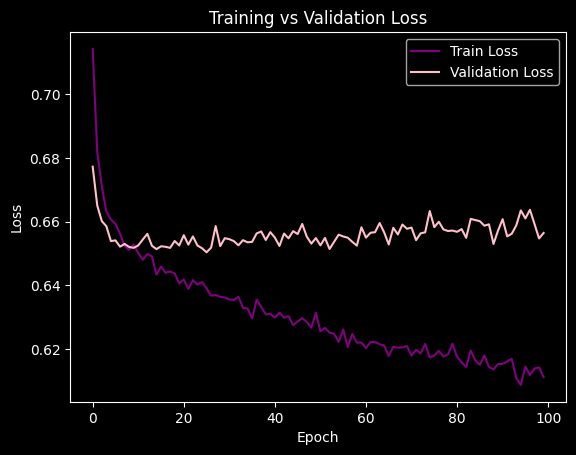

In [11]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss", color= 'purple')
plt.plot(val_losses, label="Validation Loss", color='pink')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import time

In [13]:
#train MLP with class weights now for imbalance
np.random.seed(42)
learning_rate=[0.001, 0.01, 0.1]
dropout_rate=[0.3, 0.5]
best_overall_loss= float('inf')
best_parameters= {}
best_train_losses= []
best_val_losses= []
for lr in learning_rate:
    for dropout in dropout_rate:
        torch.manual_seed(42)
        model= MLP(dropout_rate=dropout)
        criterion= nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0])) #use BCEwithlogits now for weight loss
        optimiser= torch.optim.Adam(model.parameters(),
                              lr=lr, weight_decay=1e-4)

        train_losses= []
        val_losses= []
        best_val_loss=float('inf')
        patience=10
        patience_counter=0

        start= time.time()
        for epoch in range(epochs):
            model.train()
            train_loss=0
            for x_batch,y_batch in train_ld:
                optimiser.zero_grad()
                output= model(x_batch)
                loss=criterion(output.squeeze(), y_batch)
                loss.backward()
                optimiser.step()
                train_loss += loss.item()
#validate
            model.eval()
            val_loss= 0
            with torch.no_grad():
                for x_batch, y_batch in val_ld:
                    output= model(x_batch)
                    loss= criterion(output.squeeze(), y_batch)
                    val_loss+= loss.item()
            train_losses.append(train_loss / len(train_ld))
            val_losses.append(val_loss / len(val_ld))

        #add ealry stopping
            if val_losses[-1]< best_val_loss:
                best_val_loss= val_losses[-1]
                patience_counter= 0
            #save best model
                torch.save(model.state_dict(), f"mlp_{lr}_{dropout}.pth")
            else:
                patience_counter+= 1
                if patience_counter>= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

        print(f"lr={lr}, dropout={dropout}: "f"Train Loss={train_losses[-1]:.4f}, "f"Val Loss={best_val_loss:.4f}, "
            f"Time={time.time()-start:.1f}s")

        if best_val_loss< best_overall_loss:
            best_overall_loss= best_val_loss
            best_parameters= {'lr': lr, 'dropout': dropout}
            best_train_losses= train_losses.copy()
            best_val_losses= val_losses.copy()

print(f"\nBest parameters: {best_parameters}")

Early stopping at epoch 24
lr=0.001, dropout=0.3: Train Loss=0.6411, Val Loss=0.6514, Time=71.3s
Early stopping at epoch 33
lr=0.001, dropout=0.5: Train Loss=0.6542, Val Loss=0.6517, Time=106.7s
Early stopping at epoch 19
lr=0.01, dropout=0.3: Train Loss=0.6885, Val Loss=0.6732, Time=102.8s
Early stopping at epoch 10
lr=0.01, dropout=0.5: Train Loss=0.7121, Val Loss=0.6778, Time=37.8s
Early stopping at epoch 14
lr=0.1, dropout=0.3: Train Loss=0.8518, Val Loss=0.8006, Time=102.6s
Early stopping at epoch 14
lr=0.1, dropout=0.5: Train Loss=1.6425, Val Loss=0.8006, Time=101.1s

Best parameters: {'lr': 0.001, 'dropout': 0.3}


MLP Results:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      7009
           1       0.56      0.51      0.54      1991

    accuracy                           0.80      9000
   macro avg       0.71      0.70      0.71      9000
weighted avg       0.80      0.80      0.80      9000

ROC-AUC: 0.7760304090622097
Confusion Matrix:
 [[6206  803]
 [ 966 1025]]


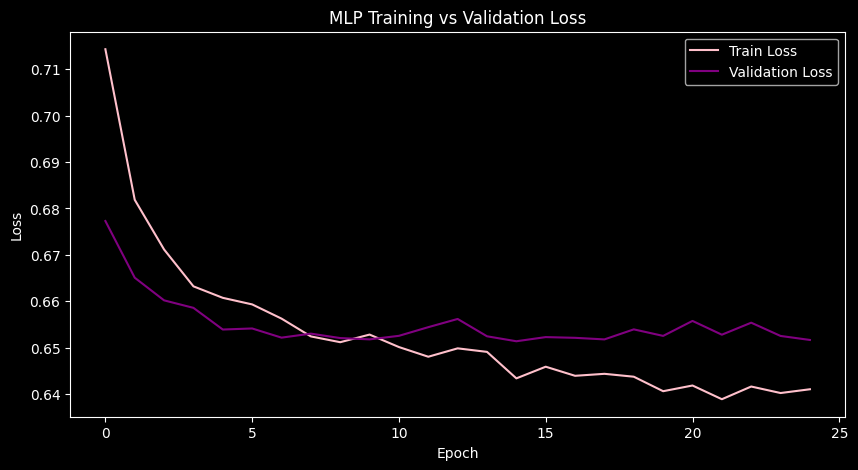

In [14]:
#mlp eval
model= MLP(dropout_rate=0.3)
model.load_state_dict(torch.load("mlp_0.001_0.3.pth"))
model.eval()
with torch.no_grad():
    y_pred_logits= model(x_test_tens).squeeze()
    y_pred_prob= torch.sigmoid(y_pred_logits).numpy()

y_pred= (y_pred_prob >= 0.5).astype(int)

print("MLP Results:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Save MLP model
torch.save(model.state_dict(), "mlp_best_model.pth")

#loss curves
plt.figure(figsize=(10, 5))
plt.plot(best_train_losses, label="Train Loss", color='pink')
plt.plot(best_val_losses, label="Validation Loss", color= 'purple')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.savefig("mlp_loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
#SVM
from sklearn.model_selection import GridSearchCV
import joblib
# Use class_weight
svm_model = SVC(kernel='rbf', probability=True,
                class_weight='balanced', random_state=42)


param_grid= {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

grid_search= GridSearchCV(svm_model, param_grid,
                           cv=5, scoring='roc_auc',
                           verbose=1, n_jobs=-1)

# Use 5000 samples
x_search, _, y_search, _ = train_test_split(
    x_training_scaled, y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

start= time.time()
grid_search.fit(x_search, y_search)
training_time_svm= time.time()- start

print(f"\nBest SVM Parameters: {grid_search.best_params_}")
print(f"SVM GridSearch Time: {training_time_svm:.2f}s")

#train of full training set
best_svm = SVC(kernel='rbf', probability=True,
               class_weight='balanced', random_state=42,
               **grid_search.best_params_)

start = time.time()
best_svm.fit(x_training_scaled, y_train)
training_time_svm = time.time() - start
print(f"SVM Full Training Time: {training_time_svm:.2f}s")

# Save SVM
joblib.dump(best_svm, "svm_best_model.pkl")


Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best SVM Parameters: {'C': 10, 'gamma': 0.01}
SVM GridSearch Time: 118.22s
SVM Full Training Time: 387.26s


['svm_best_model.pkl']


SVM Results:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      7009
           1       0.47      0.58      0.52      1991

    accuracy                           0.76      9000
   macro avg       0.67      0.70      0.68      9000
weighted avg       0.78      0.76      0.77      9000

ROC-AUC: 0.7525064101052825
Confusion Matrix:
 [[5690 1319]
 [ 838 1153]]


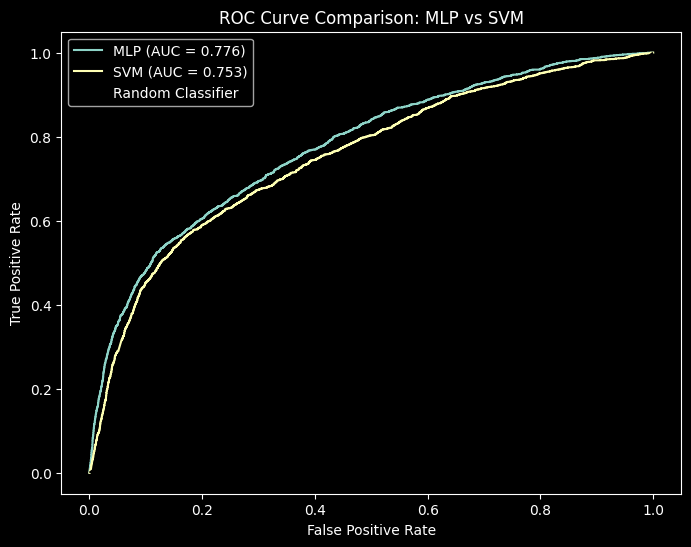

In [16]:
# Best SVM model
best_svm= grid_search.best_estimator_

y_svm_prob= best_svm.predict_proba(x_test_scaled)[:, 1]
y_svm_pred= best_svm.predict(x_test_scaled)

print("SVM Results:")
print(classification_report(y_test, y_svm_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_svm_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_svm_pred))

# Save SVM model
import joblib
joblib.dump(best_svm, "svm_best_model.pkl")


# ROC CURVE
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, y_pred_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, y_svm_prob)

mlp_auc = roc_auc_score(y_test, y_pred_prob)
svm_auc = roc_auc_score(y_test, y_svm_prob)

plt.figure(figsize=(8, 6))
plt.plot(mlp_fpr, mlp_tpr, label=f"MLP (AUC = {mlp_auc:.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: MLP vs SVM")
plt.legend()
plt.savefig("roc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()